## Setup

In [1]:
import numpy as np
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision.transforms as transforms
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.25)
import medmnist
from medmnist import INFO, Evaluator

In [13]:
# Import local files
%load_ext autoreload
%autoreload 2
from bcnn_training import *
from cnn_training import get_semi_supervised_labels, SSLDataset
from plots import *
from variational_cnn import *
from constants import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
data_flag = 'dermamnist'
download = True

info = INFO[data_flag]
task = info['task']
n_channels = info['n_channels']
n_classes = len(info['label'])

DataClass = getattr(medmnist, info['python_class'])

# Note: this preprocesses data such that it has mean 0.5 and std dev 0.5.
data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5])
])

# load the data
train_dataset = DataClass(split='train', transform=data_transform, download=download)
val_dataset = DataClass(split='val', transform=data_transform, download=download)
test_dataset = DataClass(split='test', transform=data_transform, download=download)

BATCH_SIZE = 128

# encapsulate data into dataloader form
train_loader = data.DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = data.DataLoader(dataset=val_dataset, batch_size=BATCH_SIZE, shuffle=False)
# train_loader_at_eval = data.DataLoader(dataset=train_dataset, batch_size=2*BATCH_SIZE, shuffle=False)
test_loader = data.DataLoader(dataset=test_dataset, batch_size=2*BATCH_SIZE, shuffle=False)

## Tuning

In [ ]:
def default_setup(lr=0.001, l2_weight=0.0, rho_init=-2.25):
    model = VariationalCNN(n_channels, n_classes, rho_init=rho_init)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=l2_weight)
    return model, criterion, optimizer

In [20]:
all_histories = []
for beta in [1.0, 10.0, 100.0, 1000.0]:
    model, criterion, optimizer = default_setup(lr=0.001, rho_init=-5.0)
    history = train_loop_bcnn_hard_pseudo_label(
        model, train_loader, val_loader, criterion, optimizer,
        num_epochs=20, alpha=0.5, beta=beta, num_samples=10, threshold=0.95)
    
    best = max(history, key=lambda x: x['val_auc_macro'])
    rw_mean = np.mean([param.data.mean().item() for name, param 
                       in model.named_parameters() if 'r_w' in name])
    print(f"beta={beta} | Best Val AUC: {best['val_auc_macro']:.4f} | "
          f"Final r_w mean: {rw_mean:.4f} | "
          f"Final KL: {history[-1]['train_kl_avg']:.4f} | "
          f"Final NLL: {history[-1]['train_nll_labeled']:.4f}")
    all_histories.append(history)

100%|██████████| 8/8 [00:01<00:00,  4.21it/s]


Epoch 1/20 | Train NLL: 0.9418 | Train KL (avg/batch): 2.2455 | Train Loss Unlabeled: 0.0000 | Unlabeled Examples Used: 0/0 | Val Loss: 0.8136 | Val AUC Macro: 0.8733 | Val AUC Global: 0.9459


100%|██████████| 8/8 [00:01<00:00,  4.35it/s]


Epoch 2/20 | Train NLL: 0.7856 | Train KL (avg/batch): 2.2387 | Train Loss Unlabeled: 0.0000 | Unlabeled Examples Used: 0/0 | Val Loss: 0.7866 | Val AUC Macro: 0.9005 | Val AUC Global: 0.9526


100%|██████████| 8/8 [00:01<00:00,  4.31it/s]


...

Epoch 18/20 | Train NLL: 0.4420 | Train KL (avg/batch): 1770.9073 | Train Loss Unlabeled: 0.0000 | Unlabeled Examples Used: 0/0 | Val Loss: 0.7387 | Val AUC Macro: 0.9139 | Val AUC Global: 0.9578


100%|██████████| 8/8 [00:01<00:00,  4.20it/s]


Epoch 19/20 | Train NLL: 0.4117 | Train KL (avg/batch): 1743.8163 | Train Loss Unlabeled: 0.0000 | Unlabeled Examples Used: 0/0 | Val Loss: 0.6917 | Val AUC Macro: 0.9172 | Val AUC Global: 0.9614


100%|██████████| 8/8 [00:01<00:00,  4.20it/s]

Epoch 20/20 | Train NLL: 0.4140 | Train KL (avg/batch): 1716.7483 | Train Loss Unlabeled: 0.0000 | Unlabeled Examples Used: 0/0 | Val Loss: 0.8419 | Val AUC Macro: 0.9115 | Val AUC Global: 0.9544
beta=1000.0 | Best Val AUC: 0.9218 | Final r_w mean: -3.9085 | Final KL: 1716.7483 | Final NLL: 0.4140


In [21]:
len(all_histories)

4

In [22]:
# all_histories[1] is beta=10
history_beta10 = all_histories[1]
best_epoch = max(history_beta10, key=lambda x: x['val_auc_macro'])
model_beta10, criterion, _ = default_setup(lr=0.001, rho_init=-2.25)
model_beta10.load_state_dict(best_epoch['model_state'])
model_beta10.eval()

VariationalCNN(
  (layer1): Sequential(
    (0): VariationalConv2DLayer()
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (layer2): Sequential(
    (0): VariationalConv2DLayer()
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer3): Sequential(
    (0): VariationalConv2DLayer()
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (layer4): Sequential(
    (0): VariationalConv2DLayer()
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (layer5): Sequential(
    (0): VariationalConv2DLayer()
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ce

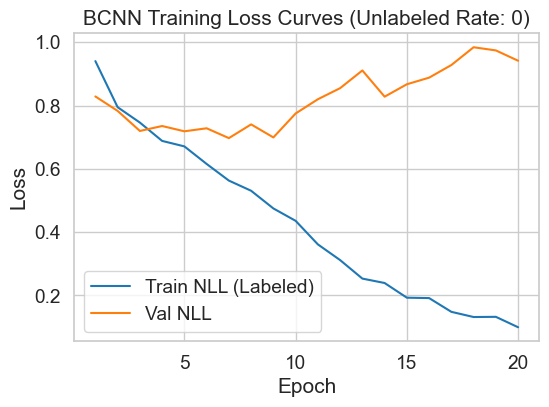

In [23]:
plot_loss_curves_bcnn(history_beta10, show_kl=False)

In [24]:
test_results_beta10 = evaluate_bayesian(model_beta10, test_loader, device='cpu')
test_results_beta10

100%|██████████| 8/8 [00:05<00:00,  1.48it/s]

preds: [5 5 2 ... 5 5 5]


{'macro_auc': 0.9100457928840504,
 'global_auc': 0.9584466099920605,
 'nll': np.float32(0.70770437),
 'per_class_auc': [0.9485442355478456,
  0.939976315171562,
  0.8814795008912656,
  0.9116834115737288,
  0.8437715470600373,
  0.9006731624484516,
  0.9441923774954628],
 'confusion_matrix': array([[3.18181818e-01, 9.09090909e-02, 3.33333333e-01, 0.00000000e+00,
         1.36363636e-01, 1.06060606e-01, 1.51515152e-02],
        [1.16504854e-01, 2.81553398e-01, 2.13592233e-01, 0.00000000e+00,
         4.85436893e-02, 3.39805825e-01, 0.00000000e+00],
        [2.72727273e-02, 1.36363636e-02, 5.77272727e-01, 0.00000000e+00,
         4.09090909e-02, 3.40909091e-01, 0.00000000e+00],
        [1.73913043e-01, 8.69565217e-02, 3.47826087e-01, 8.69565217e-02,
         4.34782609e-02, 2.60869565e-01, 0.00000000e+00],
        [1.34529148e-02, 0.00000000e+00, 1.43497758e-01, 0.00000000e+00,
         2.55605381e-01, 5.87443946e-01, 0.00000000e+00],
        [0.00000000e+00, 7.45712155e-04, 3.35570470e-

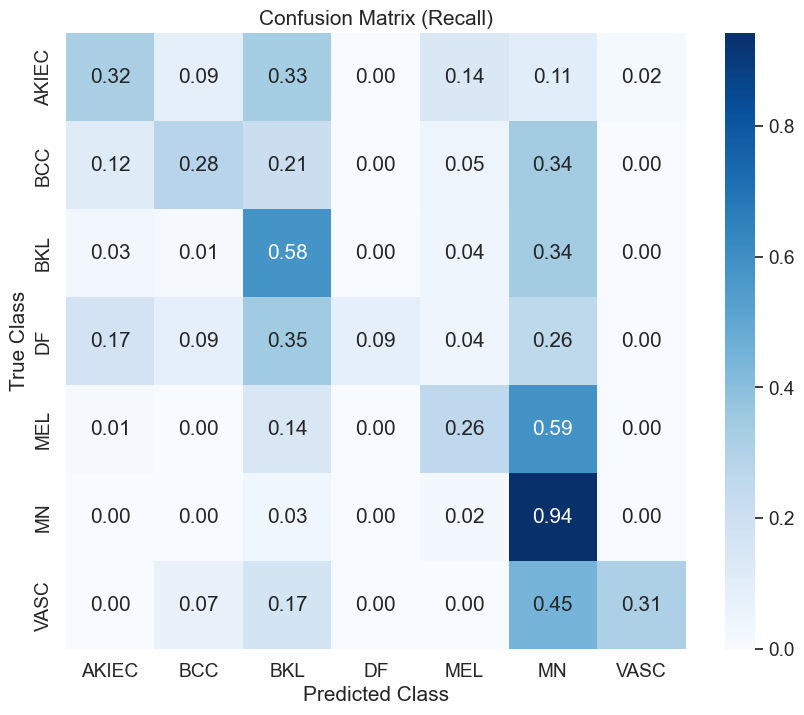

In [25]:
plot_per_class_recall(test_results_beta10['confusion_matrix'], list(short_labels.values()))